In [118]:
#Libraries
import os
import shutil #moving and coping files
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras import Model

In [119]:
import kagglehub

path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset download txt",path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset download txt /kaggle/input/celeba-dataset


In [120]:
import os
import shutil #moving and coping files

#create a smaller Dataset (500 Images)
source_folder =os.path.join(path,"img_align_celeba","img_align_celeba")

destination_folder="celeba_small/faces"

os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder,img),
        os.path.join(destination_folder,img),
    )
print("copid", len(images),"images")

copid 5000 images


In [121]:
#Data prepricessing
IMAGES_SIZE = (128,128)

BATCH_SIZE = 64

In [122]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

In [123]:
#Load Dataset
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGES_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training",
)

Found 4000 images belonging to 1 classes.


In [124]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGES_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation",
)


Found 1000 images belonging to 1 classes.


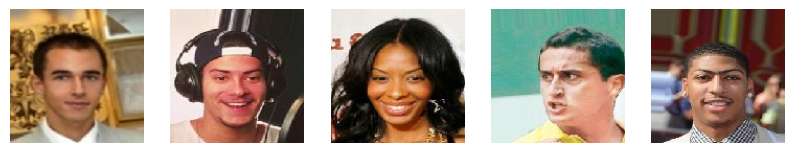

In [125]:
#Display samples images
images, _ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [138]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input

#Build convolutional autoencoder
#Encoder
input_img = Input(shape=(128,128,3))
x = Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same",

)(input_img)
x = MaxPooling2D(
    (2,2),
    padding="same",
)(x)
encoder = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same',
)(x)

In [140]:
#Decoder
x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same',

)(encoder)
x = UpSampling2D((2,2))(x)
x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
)(x)
decoder = Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same',
)(x)

In [141]:
from tensorflow.keras import Model

#create model
autoencoder=Model(
    input_img,
    decoder
)

In [142]:
#compie model
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")

In [143]:
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_22 (UpSampling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
#train model
history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step - loss: 0.5302 - val_loss: 0.4851
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.4830 - val_loss: 0.4807
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.4787 - val_loss: 0.4777
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.4775 - val_loss: 0.4764
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.4758 - val_loss: 0.4753
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - loss: 0.4751 - val_loss: 0.4746
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 0.4744 - val_loss: 0.4745
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.4741 - val_loss: 0.4740
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - loss: 0.4732 - val_loss: 0.4734
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 0.4735 - val_loss: 0.4737
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 0.4728 - val_loss: 0.4732
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/ste

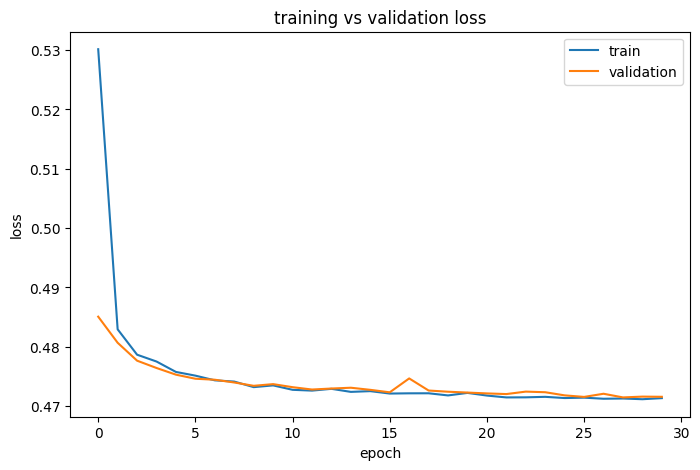

In [145]:
 #plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

In [146]:
#evaluate model
loss=autoencoder.evaluate(validation_generator)
print("validation loss",loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.4716
validation loss 0.4715815484523773


In [147]:
#reconstruct images
images,_=next(validation_generator)
reconstructed_images=autoencoder.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step 


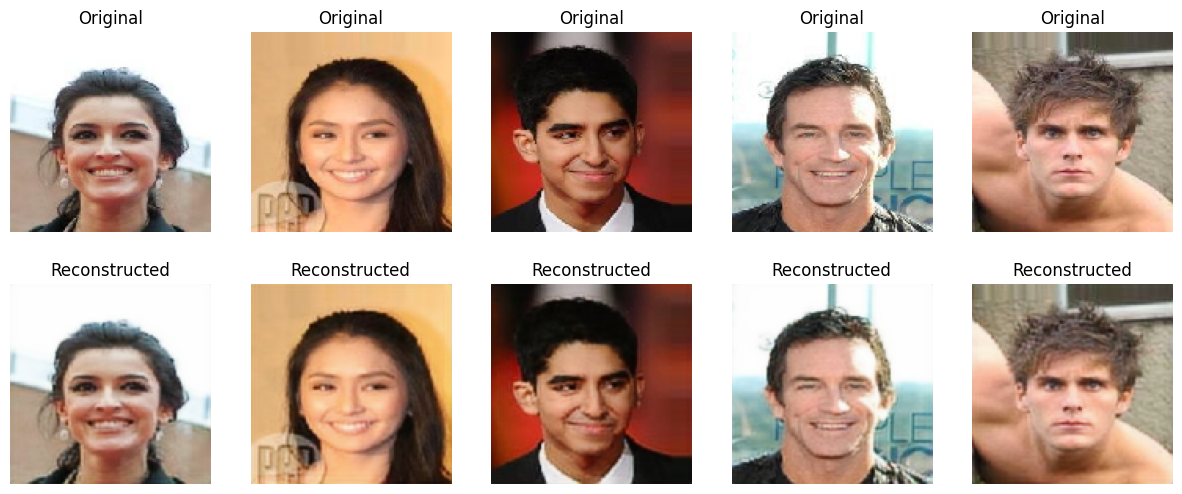

In [148]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+n+1)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()